## <font color='#00A859'>MSC_DA_CA2<font color='#1ABC9C'>
#### <font color='#'>**Programming for DA - Statistics for Data Analytics - Machine Learning for Data Analysis & Data Preparation & Visualisation
#### <font color='#1D76BA'>**Lecturer(s): Sam Weiss, Taufique Ahmed, Muhammad Iqbal and David McQuaid**
------
<font color='#E74C3C'>**Students name / ID** // Rosilene Francisca da Silva - 2021090

### Reddit Praw

In [4]:
#pip install praw

In [16]:
#pip install python-dotenv

##### Environmental Variables saved in .env

In [207]:
import pandas as pd
import praw
from datetime import datetime as dt
from dotenv import load_dotenv
from os import getenv

import warnings
warnings.filterwarnings('ignore')

# load .env file
load_dotenv()

True

The data came from a  was retrieved by Reddit API and this information was then transformed into a pandas DataFrame for Python analysis and manipulation.

#### Function collect_reddit: Collects comment from Reddit, it receives the subreddit and the search_query as Paramter, and returns a dataframe

In [208]:
def collect_reddit(subreddit, search_query):
    try:
        reddit = praw.Reddit(
            client_id=getenv('APP_ID'),
            client_secret=getenv('APP_SECRET'),
            user_agent=f"{getenv('APP_NAME')} u/{getenv('REDDIT_USERNAME')}",)

        subreddit = reddit.subreddit(subreddit)
        results = subreddit.search(search_query, limit=500)

        titles = []
        texts = []

        for submission in results:
            titles.append(submission.title)
            texts.append(submission.selftext)

        if not titles:
            print("No data retrieved. Check subreddit name, search query, or API credentials.")
        else:
            print(f"Retrieved {len(titles)} posts.")
        return pd.DataFrame({'title': titles, 'text': texts})
    except Exception as e:
        print(f"An error occurred: {e}")

# The function
transp_data = collect_reddit('Dublin', 'Dublin public transport')

# Check if the DataFrame is empty
if transp_data.empty:
    print("The DataFrame is empty.")
else:
    print(transp_data.head())

Retrieved 236 posts.
                                               title  \
0  Dublin public transport is light years ahead o...   
1               Public transport in Dublin is a joke   
2  Is there a european capital with worse public ...   
3  Why Public transportation in Dublin is so shit...   
4  Dublin ranked worst for public transport in Eu...   

                                                text  
0  A lot of negativity about the fair city these ...  
1  Currently in the city center. No busses in my ...  
2  I have been in maybe 10 European capitals and ...  
3  The buses are ALWAYS late, the time tables are...  
4                                                     


In [209]:
# Import libraries
import pandas as pd
import re
# Convert DataFrame to CSV
transp_data.to_csv('transp_data.csv', index=False)

# Confirm the operation
print("Data saved to 'transp_data.csv'")

Data saved to 'transp_data.csv'


In [210]:
transp_data.head()

,title,text
0,Dublin public transport is light years ahead o...,A lot of negativity about the fair city these ...
1,Public transport in Dublin is a joke,Currently in the city center. No busses in my ...
2,Is there a european capital with worse public ...,I have been in maybe 10 European capitals and ...
3,Why Public transportation in Dublin is so shit...,"The buses are ALWAYS late, the time tables are..."
4,Dublin ranked worst for public transport in Eu...,


In [211]:
transp_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   236 non-null    object
 1   text    236 non-null    object
dtypes: object(2)
memory usage: 3.8+ KB


In [212]:
transp_data.shape

(236, 2)

#### Data Processing 

In [213]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
import re

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    """Map POS tag to first character lemmatize() accepts"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def handle_negation(tokens):
    """Handle negations by attaching 'NOT_' prefix"""
    negation = False
    delims = "?.,!:;"
    result = []
    for token in tokens:
        if token in ['not', 'no', 'never', "n't"]:
            negation = not negation
            continue
        if negation:
            result.append("NOT_" + token)
            negation = False
        else:
            result.append(token)
        if any(char in token for char in delims):
            negation = False
    return result

In [214]:
def preprocess_text(text):
    # Clean text using regular expressions
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'\d+', '', text)      # Remove numbers
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation

    tokens = word_tokenize(text)  # Tokenization

    tokens = handle_negation(tokens)  # Handling negations

    # Removing stopwords
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization
    lemmatized_tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in filtered_tokens]

    return ' '.join(lemmatized_tokens)

# Apply preprocessing
transp_data['text_processed'] = transp_data['text'].apply(preprocess_text)
transp_data.head(2)

,title,text,text_processed
0,Dublin public transport is light years ahead o...,A lot of negativity about the fair city these ...,A lot negativity fair city day Compared year a...
1,Public transport in Dublin is a joke,Currently in the city center. No busses in my ...,Currently city center No bus direction No trai...


#### Get the Sentiment labels

In [215]:
from textblob import TextBlob

# Function to assign sentiment
def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'positive'
    elif analysis.sentiment.polarity == 0:
        return 'neutral'
    else:
        return 'negative'

# Apply function
transp_data['sentiment'] = transp_data['text'].apply(get_sentiment)
transp_data.head()

,title,text,text_processed,sentiment
0,Dublin public transport is light years ahead o...,A lot of negativity about the fair city these ...,A lot negativity fair city day Compared year a...,positive
1,Public transport in Dublin is a joke,Currently in the city center. No busses in my ...,Currently city center No bus direction No trai...,positive
2,Is there a european capital with worse public ...,I have been in maybe 10 European capitals and ...,I maybe European capital much well Metro tram ...,positive
3,Why Public transportation in Dublin is so shit...,"The buses are ALWAYS late, the time tables are...",The bus ALWAYS late time table horrible luas i...,negative
4,Dublin ranked worst for public transport in Eu...,,,neutral


#### Feature Extraction

In [226]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer()

# Fit and transform the processed text
X = vectorizer.fit_transform(transp_data['text_processed'])
y = transp_data['sentiment']

### Sentiment Analysis with SVM Model

#### Train-Test Split 

In [227]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### Train the SVM Model

In [228]:
from sklearn.svm import SVC

# Initialize the SVM model
model = SVC(kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

#### Evaluate the Model

In [229]:
from sklearn.metrics import classification_report, accuracy_score

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9154929577464789
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         5
     neutral       0.94      0.94      0.94        17
    positive       0.91      1.00      0.95        49

    accuracy                           0.92        71
   macro avg       0.62      0.65      0.63        71
weighted avg       0.85      0.92      0.88        71



#### K-Fold Cross Validation

In [230]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
scores = cross_val_score(model, X, y, cv=5)

# Print the accuracy for each fold
for i, score in enumerate(scores, 1):
    print(f"Accuracy for fold {i}: {score:.4f}")

# Print the mean accuracy and standard deviation
print(f"Mean accuracy: {scores.mean():.4f}")
print(f"Standard deviation: {scores.std():.4f}")

Accuracy for fold 1: 0.8333
Accuracy for fold 2: 0.8085
Accuracy for fold 3: 0.9149
Accuracy for fold 4: 0.8511
Accuracy for fold 5: 0.8298
Mean accuracy: 0.8475
Standard deviation: 0.0363


Cross-Validation: To assess the model's robustness and consistency, 5-fold cross-validation was used.
Across the folds, the accuracies ranged from 80.85% to 91.49%.
The overall mean accuracy was 84.75%, with a standard deviation of 3.63%.

Considerations:

The model demonstrates strong predictive capabilities for sentiment analysis.
The variance in accuracy across different folds suggests reasonable robustness to different data distributions.
The low standard deviation in cross-validation results indicates consistent model performance.
Potential areas for improvement include hyperparameter tuning, error analysis, additional feature engineering, and strategies to handle class imbalance.
Overall, your SVM model shows good performance in sentiment analysis, with areas for further improvement and refinement. The insights gained from both the initial evaluation and cross-validation provide a solid foundation for enhancing the model's capabilities.

#### Grid Search to Find Optimal Hyperparameter C

In [231]:
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

In [232]:
# specify range of parameters (C) as a list
params = {"C": [0.1, 1, 10, 100, 1000]}

model = SVC()

# Number of folds for cross-validation
folds = 5

# Set up grid search scheme
model_cv = GridSearchCV(estimator=model, param_grid=params, 
                        scoring='accuracy', 
                        cv=folds, 
                        verbose=1,
                        return_train_score=True)   

In [233]:
# fit the model - it will fit 5 folds across all values of C
model_cv.fit(X_train, y_train)  

Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(cv=5, estimator=SVC(), param_grid={'C': [0.1, 1, 10, 100, 1000]},
             return_train_score=True, scoring='accuracy', verbose=1)

#### Best Parameters and Best Score

In [234]:
print("Best parameters:", model_cv.best_params_)
print("Best score:", model_cv.best_score_)

Best parameters: {'C': 0.1}
Best score: 0.8848484848484848


#### Print All Results

In [235]:
cv_results = model_cv.cv_results_
for mean_score, params in zip(cv_results["mean_test_score"], cv_results["params"]):
    print(mean_score, params)

0.8848484848484848 {'C': 0.1}
0.8848484848484848 {'C': 1}
0.8848484848484848 {'C': 10}
0.8848484848484848 {'C': 100}
0.8848484848484848 {'C': 1000}


#### Mean Training Scores

In [237]:
for mean_train_score, params in zip(cv_results["mean_train_score"], cv_results["params"]):
    print(mean_train_score, params)

0.884848484848485 {'C': 0.1}
0.990909090909091 {'C': 1}
1.0 {'C': 10}
1.0 {'C': 100}
1.0 {'C': 1000}


#### Detailed Results

In [238]:
for key, value in cv_results.items():
    print(key, ":", value)

mean_fit_time : [0.01104641 0.00959616 0.00961261 0.0098031  0.00966372]
std_fit_time : [0.00217499 0.00037442 0.00122438 0.00098407 0.00128363]
mean_score_time : [0.00308466 0.00289655 0.00240088 0.00199733 0.00243735]
std_score_time : [1.57124036e-03 6.59951809e-04 4.90175819e-04 6.77813580e-06
 4.67082868e-04]
param_C : [0.1 1 10 100 1000]
params : [{'C': 0.1}, {'C': 1}, {'C': 10}, {'C': 100}, {'C': 1000}]
split0_test_score : [0.87878788 0.87878788 0.87878788 0.87878788 0.87878788]
split1_test_score : [0.90909091 0.90909091 0.90909091 0.90909091 0.90909091]
split2_test_score : [0.90909091 0.90909091 0.90909091 0.90909091 0.90909091]
split3_test_score : [0.84848485 0.84848485 0.84848485 0.84848485 0.84848485]
split4_test_score : [0.87878788 0.87878788 0.87878788 0.87878788 0.87878788]
mean_test_score : [0.88484848 0.88484848 0.88484848 0.88484848 0.88484848]
std_test_score : [0.02267671 0.02267671 0.02267671 0.02267671 0.02267671]
rank_test_score : [1 1 1 1 1]
split0_train_score : [0

#### Let's plot the training and test accuracies against C to get a better idea of how they change with C.

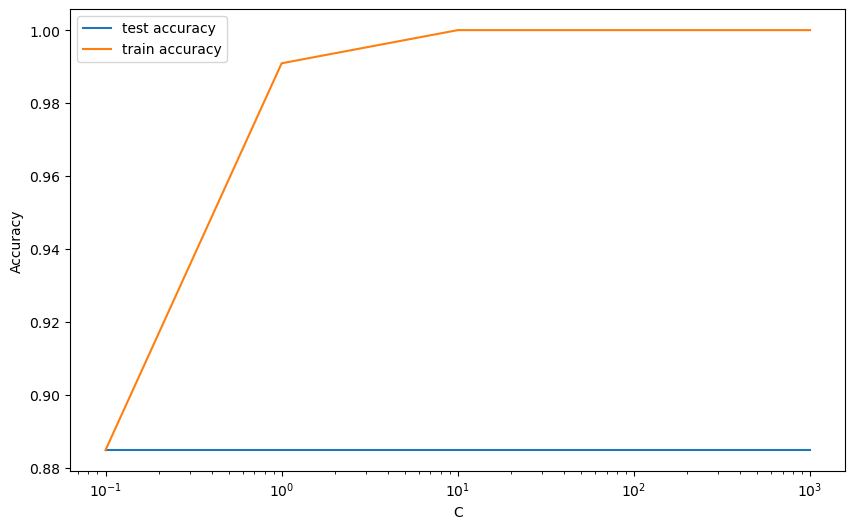

In [239]:
# plot of C versus train and test scores

plt.figure(figsize=(10, 6))
plt.plot(cv_results['param_C'], cv_results['mean_test_score'])
plt.plot(cv_results['param_C'], cv_results['mean_train_score'])
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.legend(['test accuracy', 'train accuracy'], loc='upper left')
plt.xscale('log')

#### Finally, consider the ideal C values discovered by GridSearchCV.

In [241]:
best_score = model_cv.best_score_
best_C = model_cv.best_params_['C']
print(" The highest test accuracy is {0} at C = {1}".format(best_score, best_C))

 The highest test accuracy is 0.8848484848484848 at C = 0.1


Reference: CASE STUDY (Linear SVM)

### Testing & Optimisation

The utilisation of PRAW facilitated a more efficient authentication process for the project, circumventing the complex procedures involved in direct API contacts. The intuitive methods and functions of PRAW facilitated data retrieval, enabling efficient management of rate restrictions and pagination, which is a significant difficulty when performing direct API calls. In addition, PRAW offered sophisticated features such as enhanced data filtering, which was essential for pinpointing specific discussions and comments that were pertinent to the transportation research.